In [ ]:
import os

# Define the name of the folder you want to create
folder_name = "car_project_data"

# Check if the folder already exists; if not, create it
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Directory '{folder_name}' created successfully!")
else:
    print(f"Directory '{folder_name}' already exists.")

Directory 'car_project_data' already exists.


In [ ]:
import urllib.request

# URL to a standard car price prediction dataset (from Kaggle/GitHub)
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/car%20data.csv"
output_path = "car_project_data/car_data.csv"

try:
    # Download the file directly into your newly created folder
    urllib.request.urlretrieve(url, output_path)
    print("Dataset downloaded and placed into 'car_project_data/' successfully!")
except Exception as e:
    print(f"Download failed: {e}")

Dataset downloaded and placed into 'car_project_data/' successfully!


In [ ]:
import pandas as pd

# This should work perfectly now!
df = pd.read_csv('car_project_data/car_data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Convert text columns into numbers
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

# Let's see how our new numerical columns look
df_encoded.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,False,True,False,True
1,sx4,2013,4.75,9.54,43000,0,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,False,True,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,True,False,True
4,swift,2014,4.60,6.87,42450,0,True,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

# Define your inputs (X) and output target (y)
X = df_encoded.drop(['Car_Name', 'Selling_Price'], axis=1)
y = df_encoded['Selling_Price']

# Split data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data splitting complete!")

Data splitting complete!


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train the machine learning algorithm
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training is complete!")

Model training is complete!


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate precision scores
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared (Model Accuracy): {r2 * 100:.2f}%")

Mean Squared Error: 3.48
R-squared (Model Accuracy): 84.90%


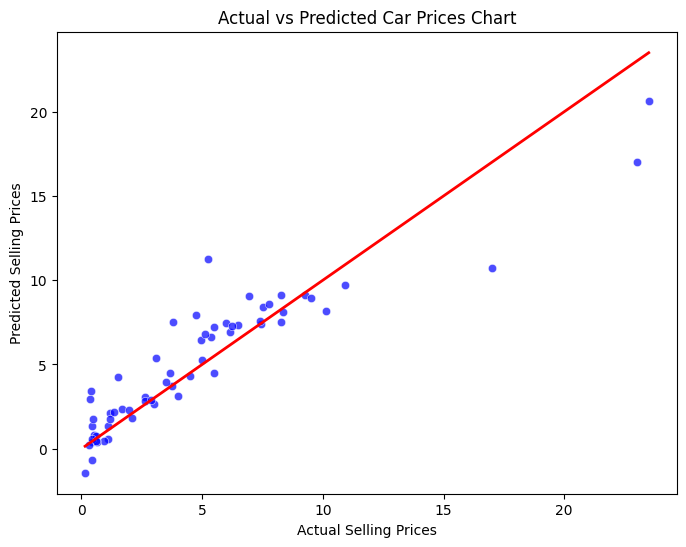

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Selling Prices")
plt.ylabel("Predicted Selling Prices")
plt.title("Actual vs Predicted Car Prices Chart")
plt.show()